In [1]:
import os
import sys
sys.path.append(os.path.abspath("/home/users/zhiyi/PROJECTS_ANALYSIS"))
os.environ['PROJ_LIB'] = '/home/users/zhiyi/.conda/envs/plot_musica/share/proj'
from matplotlib import pyplot as plt
import xarray as xr
import numpy as np
import cartopy.crs as ccrs 
from matplotlib.font_manager import FontProperties
from matplotlib.ticker import AutoMinorLocator
from matplotlib.ticker import FuncFormatter
from zhiyi.plot.Plot_2D import Plot_2D
import netCDF4 as nc
import matplotlib.patheffects as pe
from glob import glob
print('done')

done


In [2]:
scrip_filename = "/home/users/zhiyi/MUSICA_GRIDS/ne0np4.UK_ne30x16/grids/UK_ne30x16_np4_SCRIP.nc"

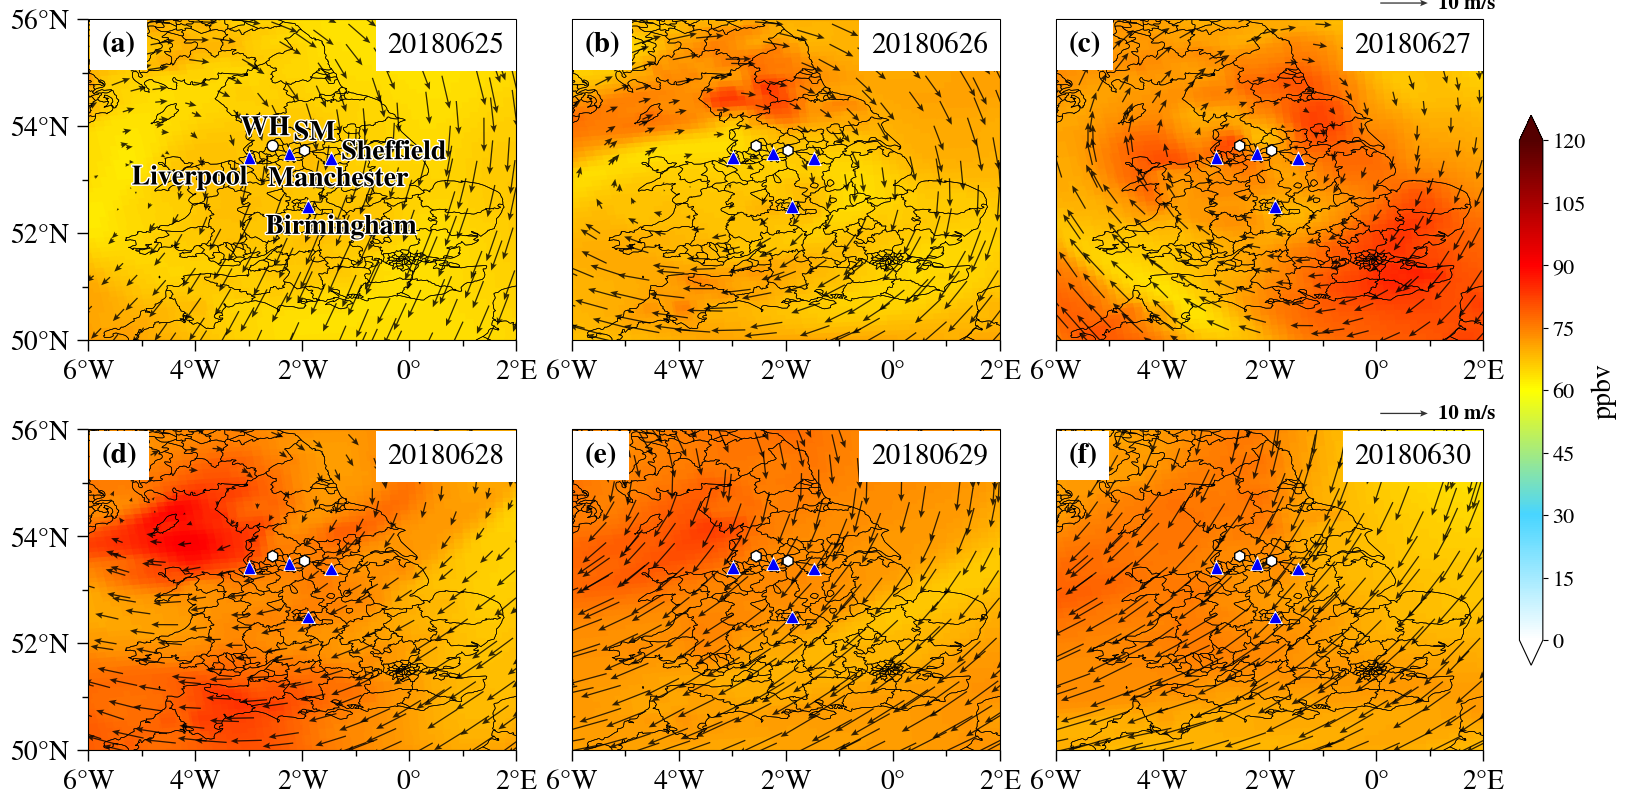

In [ ]:
#  with BB CO
base_dir = "/home/users/zhiyi/duicv/ZHIYI_SOO/P_1/MUSICA_production3.2_BB/atm/hist"
file_template = "MUSICA_production3.2_BB.cam.h3.{date_str}-00000.nc"

file_paths_BB = []
for day in range(25, 31):
    date_str = f"2018-06-{day:02d}"
    full_path = f"{base_dir}/{file_template.format(date_str=date_str)}"
    file_paths_BB.append(full_path)
datasets_BB = [xr.open_dataset(fp) for fp in file_paths_BB]

co_fields = []
for ds in datasets_BB:
    co_ugm3 = ds["CO"].isel(time=0, lev=-9) * 1e9
    co_fields.append(co_ugm3)

plot_settings = []
for idx, co_data in enumerate(co_fields):
    day = 25 + idx
    title = ""
    vmin = 0
    vmax = 120
    unit = "ppbv"
    plot_settings.append((co_data, title, vmin, vmax, unit))

with nc.Dataset(scrip_filename) as f:
    lon_scrip = f.variables['grid_center_lon'][:]
    lat_scrip = f.variables['grid_center_lat'][:]

fig, axes = plt.subplots(
    nrows=2, ncols=3, figsize=(18, 11),subplot_kw={"projection": ccrs.PlateCarree()})
axes_flat = axes.flatten()
step = 35

for i, (data, title, vmin, vmax, unit) in enumerate(plot_settings):
    ax = axes_flat[i]
    ds = datasets_BB[i]

    p = Plot_2D(
        data, scrip_file=scrip_filename, pretty_tick=True,
        lon_range=[-6, 2],
        lat_range=[50, 56],
        lon_interval=2, 
        lat_interval=2, 
        resolution="10m",
        state=True, country=True, title=title, unit=unit,
        cmin=vmin, cmax=vmax,
        title_size=15, label_size=17, feature_line_lw=0.45, shrink=0.8, unit_offset=[0.05, 0], 
        pad=0.14,
        grid_line=False,
        lonlat_line=False,
        colorbar=False,
        ax=ax,                      
    )

    if i == 0:
        # Saddleworth Moor
        lon_sm, lat_sm = -1.96000, 53.54200
        # winter hill
        lon_w, lat_w = -2.55667, 53.62944
        lon_s, lat_s = -1.4701, 53.3811
        lon_birmin, lat_birmin = -1.8904, 52.4862
        lon_manchester, lat_manchester = -2.2426, 53.4808
        lon_sheffield, lat_sheffield = -1.4701, 53.3811
        lon_liverpool, lat_liverpool = -2.9916, 53.4084
        lon_leeds, lat_leeds = -1.5491, 53.8008
        ax.plot(
            lon_sm, lat_sm,
            marker='h', markersize=6, color='white',
            path_effects=[pe.withStroke(linewidth=3, foreground='black')],
            transform=ccrs.PlateCarree()
        )
        ax.plot(
            lon_w, lat_w,
            marker='o', markersize=6, color='white',
            path_effects=[pe.withStroke(linewidth=3, foreground='black')],
            transform=ccrs.PlateCarree()
        )
        ax.plot(
            lon_birmin, lat_birmin,
            marker='^', markersize=7, color='blue',
            path_effects=[pe.withStroke(linewidth=2.2, foreground='white')],
            transform=ccrs.PlateCarree()
        )        
        ax.plot(
            lon_liverpool, lat_liverpool,
            marker='^', markersize=7, color='blue',
            path_effects=[pe.withStroke(linewidth=2.2, foreground='white')],
            transform=ccrs.PlateCarree()
        ) 
        ax.plot(
            lon_manchester, lat_manchester,
            marker='^', markersize=7, color='blue',
            path_effects=[pe.withStroke(linewidth=2.2, foreground='white')],
            transform=ccrs.PlateCarree()
        )
        ax.plot(
            lon_sheffield, lat_sheffield,
            marker='^', markersize=7, color='blue',
            path_effects=[pe.withStroke(linewidth=2.2, foreground='white')],
            transform=ccrs.PlateCarree()
        )  
        ax.annotate(
            "SM",
            xy=(lon_sm, lat_sm),
            xytext=(lon_sm - 0.2, lat_sm + 0.2),
            textcoords=ccrs.PlateCarree()._as_mpl_transform(ax),
            fontsize=20, weight='semibold', color='black',
            path_effects=[pe.withStroke(linewidth=2, foreground='white')],
            # arrowprops=dict(arrowstyle="->", lw=1.0, color="black",
            #                 connectionstyle="arc3,rad=0.2"),
        )
        ax.annotate(
            "WH",
            xy=(lon_w, lat_w),
            xytext=(lon_w - 0.6, lat_w + 0.2),
            textcoords=ccrs.PlateCarree()._as_mpl_transform(ax),
            fontsize=20, weight='semibold', color='black',
            path_effects=[pe.withStroke(linewidth=2, foreground='white')],
            # arrowprops=dict(arrowstyle="->", lw=1.0, color="black",
            #                 connectionstyle="arc3,rad=-0.2"),
        )
        ax.annotate(
            "Manchester",
            xy=(lon_manchester, lat_manchester),
            xytext=(lon_manchester - 0.4, lat_manchester - 0.6), 
            textcoords=ccrs.PlateCarree()._as_mpl_transform(ax),
            fontsize=20, weight='semibold', color='black',
            path_effects=[pe.withStroke(linewidth=2, foreground='white')],
            # arrowprops=dict(arrowstyle="->", lw=1.0, color="black",
            #                 connectionstyle="arc3,rad=-0.2"),
        )
        ax.annotate(
            "Liverpool",
            xy=(lon_liverpool, lat_liverpool),
            xytext=(lon_liverpool - 2.2, lat_liverpool - 0.5), 
            textcoords=ccrs.PlateCarree()._as_mpl_transform(ax),
            fontsize=20, weight='semibold', color='black',
            path_effects=[pe.withStroke(linewidth=2, foreground='white')],
            # arrowprops=dict(arrowstyle="->", lw=1.0, color="black",
            #                 connectionstyle="arc3,rad=-0.2"),
        )
        ax.annotate(
            "Sheffield",
            xy=(lon_sheffield, lat_sheffield),
            xytext=(lon_sheffield + 0.2, lat_sheffield ),
            textcoords=ccrs.PlateCarree()._as_mpl_transform(ax),
            fontsize=20, weight='semibold', color='black',
            path_effects=[pe.withStroke(linewidth=2, foreground='white')],
            # arrowprops=dict(arrowstyle="->", lw=1.0, color="black",
            #                 connectionstyle="arc3,rad=-0.2"),
        )       
        ax.annotate(
            "Birmingham",
            xy=(lon_birmin, lat_birmin),
            xytext=(lon_birmin - 0.8, lat_birmin - 0.5),
            textcoords=ccrs.PlateCarree()._as_mpl_transform(ax),
            fontsize=20, weight='semibold', color='black',
            path_effects=[pe.withStroke(linewidth=2, foreground='white')],
            # arrowprops=dict(arrowstyle="->", lw=1.0, color="black",
            #                 connectionstyle="arc3,rad=-0.2"),
        )        

    if i in [1, 2, 3, 4, 5]:
        lon_sm, lat_sm = -1.96000, 53.54200
        # winter hill
        lon_w, lat_w = -2.55667, 53.62944
        lon_s, lat_s = -1.4701, 53.3811
        lon_liver, lat_liver = -2.9916, 53.4084
        lon_birmin, lat_birmin = -1.8904, 52.4862
        ax.plot(
            lon_sm, lat_sm,
            marker='h', markersize=6, color='white',
            path_effects=[pe.withStroke(linewidth=3, foreground='black')],
            transform=ccrs.PlateCarree()
        )
        ax.plot(
            lon_w, lat_w,
            marker='h', markersize=6, color='white',
            path_effects=[pe.withStroke(linewidth=3, foreground='black')],
            transform=ccrs.PlateCarree()
        )
        ax.plot(
            lon_birmin, lat_birmin,
            marker='^', markersize=7, color='blue',
            path_effects=[pe.withStroke(linewidth=2.2, foreground='white')],
            transform=ccrs.PlateCarree()
        )        
        ax.plot(
            lon_liverpool, lat_liverpool,
            marker='^', markersize=7, color='blue',
            path_effects=[pe.withStroke(linewidth=2.2, foreground='white')],
            transform=ccrs.PlateCarree()
        ) 
        ax.plot(
            lon_manchester, lat_manchester,
            marker='^', markersize=7, color='blue',
            path_effects=[pe.withStroke(linewidth=2.2, foreground='white')],
            transform=ccrs.PlateCarree()
        )
        ax.plot(
            lon_sheffield, lat_sheffield,
            marker='^', markersize=7, color='blue',
            path_effects=[pe.withStroke(linewidth=2.2, foreground='white')],
            transform=ccrs.PlateCarree()
        ) 
    # 850 hpa 
    if "time" in ds.dims:
        u_field = ds["U"].isel(time=0, lev=-9).values 
        v_field = ds["V"].isel(time=0, lev=-9).values 
    else:
        u_field = ds["U"].isel(lev=-9).values
        v_field = ds["V"].isel(lev=-9).values

    lon_plot = lon_scrip[::step]
    lat_plot = lat_scrip[::step]
    u_plot = u_field[::step]
    v_plot = v_field[::step]
 
    q = ax.quiver(
        lon_plot, lat_plot, u_plot, v_plot,
        scale=90, color='k', width=0.003, alpha=0.8,
        headaxislength=5, headwidth=5, headlength=6,
        transform=ccrs.PlateCarree()
    )   
    font_prop = FontProperties(size=15, weight='bold')
    if i in [2, 5]:
        ax.quiverkey(
            q, X=0.87, Y=1.05, U=10, label='10 m/s',
            labelpos='E', coordinates='axes',
            fontproperties=font_prop
        )   
    if i == 0:
        ax.set_ylabel("",fontsize=25, labelpad=15)
        ax.yaxis.set_tick_params(labelleft=True, labelright=False)
        ax.yaxis.set_minor_locator(AutoMinorLocator(2))
        ax.tick_params(axis='y', which='major', labelsize=20, pad=6, length=8, width=1 )
        ax.tick_params(axis='y', which='minor', labelsize=18*0.8, length=4, width=1 )
    elif i == 3:
        ax.set_ylabel("", fontsize=25, labelpad=25)
        ax.yaxis.set_tick_params(labelleft=True, labelright=False)
        ax.yaxis.set_minor_locator(AutoMinorLocator(2))
        ax.tick_params(axis='y', which='major', labelsize=20, pad=6, length=8, width=1 )
        ax.tick_params(axis='y', which='minor', labelsize=18*0.8, length=4, width=1 )
    elif i == 1:
        ax.set_ylabel("", fontsize=25, labelpad=25)
        ax.yaxis.set_tick_params(labelleft=False, labelright=False, left=False, right=False)
    elif i == 2:
        ax.set_ylabel("", fontsize=25, labelpad=25)
        ax.yaxis.set_tick_params(labelleft=False, labelright=False, left=False, right=False)
    elif i == 4:
        ax.set_ylabel("", fontsize=25, labelpad=25)
        ax.yaxis.set_tick_params(labelleft=False, labelright=False, left=False, right=False)
    elif i == 5:
        ax.set_ylabel("", fontsize=25, labelpad=25)
        ax.yaxis.set_tick_params(labelleft=False, labelright=False, left=False, right=False)

    lon_min, lon_max = -6, 2
    xticks = np.arange(np.ceil(lon_min), np.floor(lon_max)+1, 2)
    xticklabels = []
    for val in xticks:
        if val < 0:
            xticklabels.append(f"{int(-val)}°W")
        elif val > 0:
            xticklabels.append(f"{int(val)}°E")
        else:
            xticklabels.append('0°')
    ax.set_xticks(xticks)
    ax.set_xticklabels(xticklabels, fontsize=20)
    ax.xaxis.set_minor_locator(AutoMinorLocator(2))   
     
    ax.tick_params(axis='x', which='major', labelsize=20, pad=6, length=8, width=1 )
    ax.tick_params(axis='x', which='minor', labelsize=18*0.8, length=4, width=1 ) 
    
    day = 25 + i
    date_str = f"201806{day:02d}"
    ax.text(0.972, 0.96, date_str,transform=ax.transAxes, 
            fontsize=21,
            va='top', ha='right',
            bbox=dict(facecolor='white', edgecolor='none', boxstyle='square, pad=0.4', alpha=1))
fig.subplots_adjust(wspace=0.13, hspace=-0.06)

letters = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)']
for i, ax in enumerate(axes_flat):
    ax.text(0.030, 0.96, letters[i], transform=ax.transAxes, 
            fontsize=21, va='top', 
            ha='left', weight='bold',
            bbox=dict(facecolor='white', edgecolor='none', boxstyle='square, pad=0.4',  alpha=1))

cbar_ax = fig.add_axes([0.92, 0.24, 0.013, 0.5])
cb = fig.colorbar(p.im, cax=cbar_ax,
                  orientation='vertical',
                  extend='both',
                  ticks=np.arange(0, 121, 15)
                  )
cb.ax.tick_params(labelsize=16)
cb.set_label('ppbv', fontsize=20)                   
cb.ax.yaxis.set_label_position('right')             
cb.ax.yaxis.set_label_coords(3.06, 0.5) 

def lon_formatter(x, pos=None):
    if x == 0:
        return "0°"
    elif x > 0:
        return f"{x:.0f}°E"
    else:
        return f"{abs(x):.0f}°W"
def lat_formatter(y, pos=None):
    if y == 0:
        return "0°"
    elif y > 0:
        return f"{y:.0f}°N"
    else:
        return f"{abs(y):.0f}°S"
    
for _ax in axes_flat:
    _ax.xaxis.set_major_formatter(FuncFormatter(lon_formatter))
    _ax.yaxis.set_major_formatter(FuncFormatter(lat_formatter))
